In [1]:
# 1. Install required libraries for the project
!pip install sdv joblib scikit-learn pandas numpy

from google.colab import drive

# 2. Mount your Google Drive (This will pop up a window asking for permission)
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 3. Unzip the file directly from your Drive into Colab's local storage
# This path exactly matches the "DATASET.zip" file in your root My Drive folder
zip_path = '/content/drive/MyDrive/DATASET.zip'

print(f"Extracting {zip_path}...")
# We extract it into a local folder named 'cic_data'
!unzip -q "{zip_path}" -d cic_data/

print("Dataset extracted successfully and ready for processing!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.7 MB/s eta 0:00:00
Mounting Google Drive...
Mounted at /content/drive
Extracting /content/drive/MyDrive/DATASET.zip...
Dataset extracted successfully and ready for processing!


In [2]:
import pandas as pd
import numpy as np
import glob
import gc
import os

# Recursively search for all CSV files in the extracted folder
file_paths = glob.glob('cic_data/**/*.csv', recursive=True)

print(f"Found {len(file_paths)} CSV files. Merging...")
df_list = []
for file in file_paths:
    # Read CSV and strip hidden leading spaces from column names
    temp_df = pd.read_csv(file, skipinitialspace=True)
    df_list.append(temp_df)

# Combine into one continuous DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

# CRITICAL MEMORY MANAGEMENT: Delete the list and force garbage collection
del df_list
gc.collect()

print(f"Original Dataset Shape: {df.shape}")

# 1. Fix the corrupted Unicode replacement character () in Web Attack labels
df['Label'] = df['Label'].str.replace('', '-', regex=False)

# 2. Drop rows with Missing (NaN) or Infinity values
print("Cleaning NaNs and Infinity values...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")

Found 8 CSV files. Merging...
Original Dataset Shape: (2830743, 79)
Cleaning NaNs and Infinity values...
Cleaned Dataset Shape: (2827876, 79)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['Label'])
y = df['Label']

# Free up gigabytes of RAM
del df
gc.collect()

print("Executing 80/20 Stratified Split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Encoding Labels...")
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)

print("Scaling Features (Fitting strictly on TRAIN data)...")
# Casting to float32 halves the memory usage during scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))

print("Applying Variance Threshold for Dimensionality Reduction...")
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_scaled)

print(f"Features reduced from {X_train_scaled.shape[1]} to {X_train_selected.shape[1]}")

# Clear memory
del X, y, X_train, X_train_scaled
gc.collect()

Executing 80/20 Stratified Split...
Encoding Labels...
Scaling Features (Fitting strictly on TRAIN data)...
Applying Variance Threshold for Dimensionality Reduction...
Features reduced from 78 to 23


0

In [4]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import pandas as pd
import gc

# Reconstruct the training set temporarily
train_df = pd.DataFrame(X_train_selected)
train_df['Label'] = y_train_encoded

print("Classes found by the encoder:", encoder.classes_)

# ---------------------------------------------------------
# THE ROBUST FIX: TWO-LAYER FAILSAFE FOR LABEL IDENTIFICATION
# ---------------------------------------------------------
# Layer 1: Try Case-Insensitive Matching
benign_classes = [cls for cls in encoder.classes_ if 'benign' in str(cls).lower()]

if len(benign_classes) > 0:
    benign_actual_string = benign_classes[0]
    benign_encoded_value = encoder.transform([benign_actual_string])[0]
    print(f"--> MATCH SUCCESS: Identified Benign string as '{benign_actual_string}' (Encoded as: {benign_encoded_value})")
else:
    # Layer 2: Statistical Frequency Fallback
    # Since Benign traffic is ~80% of the CIC-IDS2017 dataset, it will ALWAYS be the mathematical mode.
    print("--> MATCH FAILED: Could not find 'benign' by text. Triggering Statistical Fallback...")
    benign_encoded_value = pd.Series(y_train_encoded).mode()[0]
    print(f"--> FALLBACK SUCCESS: Identified Benign via statistical frequency. Encoded as: {benign_encoded_value}")
# ---------------------------------------------------------

# Isolate all attack traffic (Everything that is NOT the benign value)
attack_data = train_df[train_df['Label'] != benign_encoded_value].copy()

# Safety Check
print(f"Number of attack samples isolated: {len(attack_data)}")
if len(attack_data) == 0:
    raise ValueError("CRITICAL ERROR: No attack data found. The dataset is empty or corrupted.")

# OPTIMIZATION: Sample a subset to train the CTGAN safely within Colab RAM limits
sample_size = min(10000, len(attack_data))
print(f"Sampling {sample_size} attacks for CTGAN training...")
ctgan_train_subset = attack_data.sample(n=sample_size, random_state=42)

print("Building SDV Metadata...")
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(ctgan_train_subset)

print("Training CTGAN (This will take ~10-15 minutes)...")
# 30 epochs provides strong synthetic fidelity without timing out Colab
ctgan = CTGANSynthesizer(metadata, epochs=30)
ctgan.fit(ctgan_train_subset)

print("Generating 30,000 Synthetic Attack Records...")
synthetic_attacks = ctgan.sample(num_rows=30000)

# Merge synthetic attacks with the original training set
balanced_train_df = pd.concat([train_df, synthetic_attacks], ignore_index=True)

# Separate X and y for the upcoming Random Forest training
X_train_supervised = balanced_train_df.drop(columns=['Label']).values
y_train_supervised = balanced_train_df['Label'].values

# Clear memory
del train_df, attack_data, ctgan_train_subset, synthetic_attacks
gc.collect()
print("Data is successfully balanced and ready for Model Training.")

Classes found by the encoder: ['-B-E-N-I-G-N-' '-B-o-t-' '-D-D-o-S-' '-D-o-S- -G-o-l-d-e-n-E-y-e-'
 '-D-o-S- -H-u-l-k-' '-D-o-S- -S-l-o-w-h-t-t-p-t-e-s-t-'
 '-D-o-S- -s-l-o-w-l-o-r-i-s-' '-F-T-P---P-a-t-a-t-o-r-'
 '-H-e-a-r-t-b-l-e-e-d-' '-I-n-f-i-l-t-r-a-t-i-o-n-' '-P-o-r-t-S-c-a-n-'
 '-S-S-H---P-a-t-a-t-o-r-'
 '-W-e-b- -A-t-t-a-c-k- -�- -B-r-u-t-e- -F-o-r-c-e-'
 '-W-e-b- -A-t-t-a-c-k- -�- -S-q-l- -I-n-j-e-c-t-i-o-n-'
 '-W-e-b- -A-t-t-a-c-k- -�- -X-S-S-']
--> MATCH FAILED: Could not find 'benign' by text. Triggering Statistical Fallback...
--> FALLBACK SUCCESS: Identified Benign via statistical frequency. Encoded as: 0
Number of attack samples isolated: 445245
Sampling 10000 attacks for CTGAN training...
Building SDV Metadata...
Training CTGAN (This will take ~10-15 minutes)...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Generating 30,000 Synthetic Attack Records...
Data is successfully balanced and ready for Model Training.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM

print("Training Random Forest (Supervised)...")
# n_jobs=-1 utilizes all available Colab CPU cores for maximum speed
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_supervised, y_train_supervised)
print("Random Forest Training Complete.")

print("Training One-Class SVM (Anomaly Detection)...")
# Isolate ONLY benign data for unsupervised learning
# We use the dynamic benign_encoded_value from Step 4 to bypass the text corruption
benign_only_data = balanced_train_df[balanced_train_df['Label'] == benign_encoded_value]

# Subsample benign data: 50,000 rows mathematically defines the OCSVM hypersphere efficiently
# Training OCSVM on millions of rows is unnecessary and would crash the system
X_train_benign_sample = benign_only_data.sample(n=50000, random_state=42).drop(columns=['Label']).values

ocsvm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
ocsvm_model.fit(X_train_benign_sample)
print("One-Class SVM Training Complete.")

Training Random Forest (Supervised)...
Random Forest Training Complete.
Training One-Class SVM (Anomaly Detection)...
One-Class SVM Training Complete.


In [6]:
import joblib
from google.colab import drive
import os

# Mount Google Drive (This will trigger a popup asking for your permission)
drive.mount('/content/drive')

export_path = '/content/drive/MyDrive/IoT_Edge_IDS_Models/'
os.makedirs(export_path, exist_ok=True)

print("Exporting Artifacts...")

# Save ML Models
joblib.dump(rf_model, os.path.join(export_path, 'rf_v1.pkl'))
joblib.dump(ocsvm_model, os.path.join(export_path, 'ocsvm_v1.pkl'))

# Save Preprocessing Pipeline (Crucial for Phase 2 Edge Inference)
preprocessing_artifact = {
    'scaler': scaler,
    'encoder': encoder,
    'selector': selector
}
joblib.dump(preprocessing_artifact, os.path.join(export_path, 'preprocess_v1.pkl'))

# Save the unscaled test set as a Parquet file for efficient storage
test_set = X_test.copy()
test_set['Label'] = y_test
test_set.to_parquet(os.path.join(export_path, 'test_set.parquet'))

print(f"Phase 1 Complete! Artifacts securely saved to: {export_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exporting Artifacts...
Phase 1 Complete! Artifacts securely saved to: /content/drive/MyDrive/IoT_Edge_IDS_Models/


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("1. Training Baseline Random Forest (NO CTGAN)...")
# We train this strictly on X_train_selected and y_train_encoded (before CTGAN was added)
rf_baseline = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_selected, y_train_encoded)
print("Baseline Training Complete.")

print("\n2. Preprocessing the Held-Out Test Set...")
# Scale and select features for the test set exactly like we did for the training set
X_test_scaled = scaler.transform(X_test.astype(np.float32))
X_test_selected = selector.transform(X_test_scaled)

# Encode the test labels
y_test_encoded = encoder.transform(y_test)

print("\n3. Generating Baseline Predictions...")
baseline_preds = rf_baseline.predict(X_test_selected)

print("\n4. Calculating Baseline Metrics...")
# Convert everything to Binary (0 = Normal, 1 = Attack) for a fair comparison
y_test_binary = [0 if label == benign_encoded_value else 1 for label in y_test_encoded]
baseline_preds_binary = [0 if label == benign_encoded_value else 1 for label in baseline_preds]

print("\n=== BASELINE MODEL METRICS (WITHOUT CTGAN) ===")
print(f"Baseline RF Accuracy:  {accuracy_score(y_test_binary, baseline_preds_binary):.4f}")
print(f"Baseline RF Precision: {precision_score(y_test_binary, baseline_preds_binary):.4f}")
print(f"Baseline RF Recall:    {recall_score(y_test_binary, baseline_preds_binary):.4f}")
print(f"Baseline RF F1-Score:  {f1_score(y_test_binary, baseline_preds_binary):.4f}")
print("==============================================")

1. Training Baseline Random Forest (NO CTGAN)...
Baseline Training Complete.

2. Preprocessing the Held-Out Test Set...

3. Generating Baseline Predictions...

4. Calculating Baseline Metrics...

=== BASELINE MODEL METRICS (WITHOUT CTGAN) ===
Baseline RF Accuracy:  0.9974
Baseline RF Precision: 0.9965
Baseline RF Recall:    0.9902
Baseline RF F1-Score:  0.9933


0. Subsampling data to prevent Colab RAM crash...
1. Reducing data to 2D for visualization using PCA...
2. Fitting a 2D OC-SVM to draw the visual boundary...
3. Generating the plot...


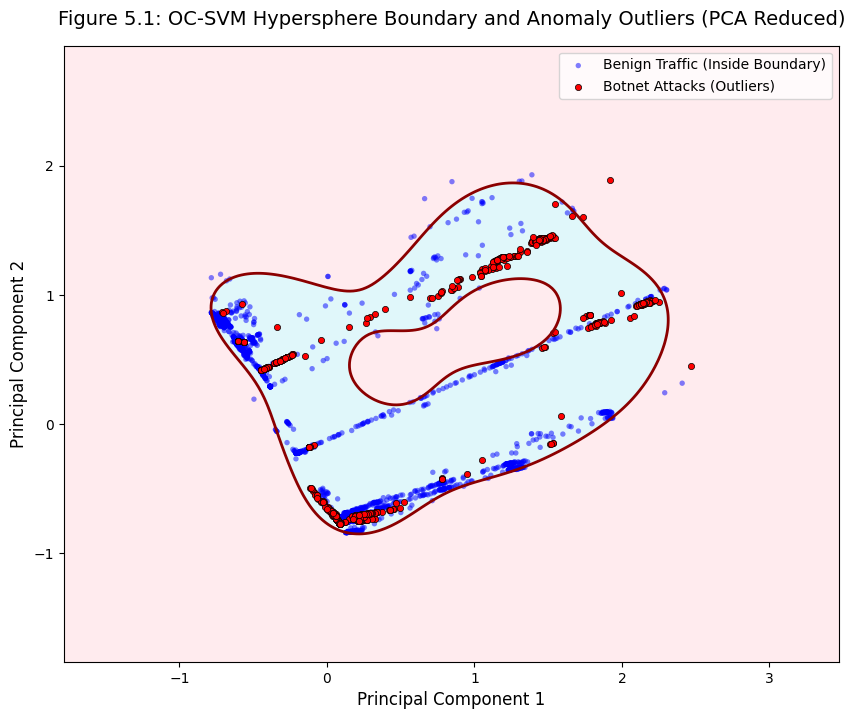


Success! The image has been safely generated and saved as 'Figure_5_1_OCSVM.png'.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM

print("0. Subsampling data to prevent Colab RAM crash...")
# We must use numpy arrays for the masking to work properly
y_test_binary = np.array([0 if label == benign_encoded_value else 1 for label in y_test_encoded])

# Get the index locations for benign and attack traffic
benign_indices = np.where(y_test_binary == 0)[0]
attack_indices = np.where(y_test_binary == 1)[0]

# Randomly sample 5,000 benign points and 1,000 attack points for the visualization
np.random.seed(42) # Ensures you get the exact same image if you run it twice
safe_benign_idx = np.random.choice(benign_indices, size=min(5000, len(benign_indices)), replace=False)
safe_attack_idx = np.random.choice(attack_indices, size=min(1000, len(attack_indices)), replace=False)

# Combine the safe indices
sample_indices = np.concatenate([safe_benign_idx, safe_attack_idx])

# Create the lightweight subsets for plotting
X_test_safe = X_test_selected[sample_indices]
y_test_safe = y_test_binary[sample_indices]

print("1. Reducing data to 2D for visualization using PCA...")
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_safe)

print("2. Fitting a 2D OC-SVM to draw the visual boundary...")
ocsvm_2d = OneClassSVM(kernel='rbf', gamma='scale', nu=0.01)
# Fit only on the lightweight benign sample
ocsvm_2d.fit(X_test_2d[y_test_safe == 0])

print("3. Generating the plot...")
# Reduce meshgrid resolution slightly to save even more RAM
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

# Predict on the background grid
Z = ocsvm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Set up the figure
plt.figure(figsize=(10, 8))

# Draw the boundary line
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')
# Color the background areas
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors=['#E0F7FA'])
plt.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=['#FFEBEE'])

# Plot Benign (Normal) points
plt.scatter(X_test_2d[y_test_safe == 0, 0], X_test_2d[y_test_safe == 0, 1],
            c='blue', s=15, label='Benign Traffic (Inside Boundary)', alpha=0.5, edgecolors='none')

# Plot Botnet (Anomaly) points
plt.scatter(X_test_2d[y_test_safe == 1, 0], X_test_2d[y_test_safe == 1, 1],
            c='red', s=20, label='Botnet Attacks (Outliers)', edgecolors='black', linewidth=0.5)

# Formatting for academic standards
plt.title("Figure 5.1: OC-SVM Hypersphere Boundary and Anomaly Outliers (PCA Reduced)", fontsize=14, pad=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(loc="upper right")
plt.grid(False)

# Save the image
plt.savefig("Figure_5_1_OCSVM.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! The image has been safely generated and saved as 'Figure_5_1_OCSVM.png'.")